## Shear correlator is plotted using data from lattice calculated in arxiv:2601.14967

[[0.13888889 1.09645145]
 [0.16666667 1.04501133]
 [0.19444444 1.00470394]
 [0.22222222 0.95425634]
 [0.25       0.905676  ]
 [0.27777778 0.85888702]
 [0.30555556 0.80069109]
 [0.33333333 0.75357143]
 [0.36111111 0.6943315 ]
 [0.38888889 0.63456919]
 [0.41666667 0.56984704]
 [0.44444444 0.51970958]
 [0.47222222 0.47941521]
 [0.5        0.47712938]]
[[0.13888889 1.12169296]
 [0.16666667 1.05758835]
 [0.19444444 1.00063315]
 [0.22222222 0.95128561]
 [0.25       0.90057957]
 [0.27777778 0.84713894]
 [0.30555556 0.78359121]
 [0.33333333 0.71850697]
 [0.36111111 0.65503944]
 [0.38888889 0.58961812]
 [0.41666667 0.54757695]
 [0.44444444 0.48206437]
 [0.47222222 0.44357128]
 [0.5        0.42034259]]
[[0.13888889 1.12323005]
 [0.16666667 1.09560902]
 [0.19444444 1.06291111]
 [0.22222222 1.02496424]
 [0.25       0.9977049 ]
 [0.27777778 0.98399996]
 [0.30555556 0.9579151 ]
 [0.33333333 0.93856493]
 [0.36111111 0.90361185]
 [0.38888889 0.87642491]
 [0.41666667 0.84259648]
 [0.44444444 0.81595031

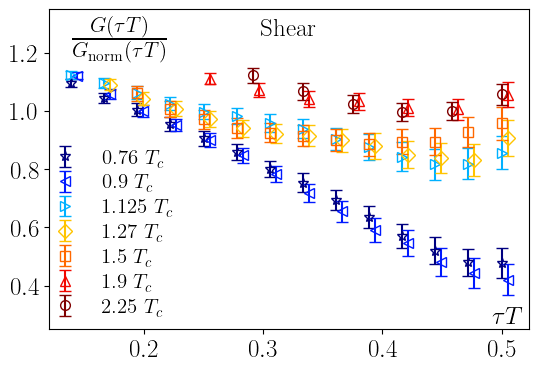

Process completed


In [10]:
from numpy import *
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig = plt.figure(figsize=(6, 4))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.rc('text',usetex=True) ; plt.rc('font',family='serif', size=18)
plt.rcParams['font.sans-serif'] = 'Times New Roman'
axes = plt.gca()

cm_subsection = hstack((linspace(0, 0.3, 3), linspace(0.70, 1.0, 4)))
colors = [cm.jet(x) for x in cm_subsection]
adjust_x = 0.005
temperatures = ['0_76', '0_9', '1_125', '1_2667', '1_5', '1_9', '2_25']
markers = ['*', '<', '>', 'D', 's', '^', 'o']

datas = []
for i, temperature in enumerate(temperatures):
    datas.append(loadtxt(f'./data/{temperature}Tc/{temperature}Tc_Corr_Shear_Flow_Extrap_Separ_25_1.dat'))
    format_temperature = temperature.replace('_', '.')
    if format_temperature == '1.2667':
        format_temperature = '1.27'
    print(datas[i][:,0:2])
    plt.errorbar(datas[i][:, 0]+(i % 2) * adjust_x, datas[i][:, 1], yerr=datas[i][:, 2], fmt=markers[i], markersize=7,
                 markerfacecolor='none', color=colors[i], capsize=4, label=rf'{format_temperature} $T_c$') # star
    
plt.xlabel(r'$\tau T$', labelpad=-40, position=(0.98, 0.15), ha='right', fontsize=18)
plt.ylabel(r'$\frac{G(\tau T)}{G_{\rm{norm}}(\tau T)}$', labelpad=-45, position=(0.15,0.98), ha='left', va='top', rotation=0, fontsize=22)
plt.text(0.5, 0.85, 'Shear', fontsize=18, color='black',
         alpha=1, ha='center', va='center', transform=plt.gcf().transFigure, rotation=0)

plt.ylim(0.25, 1.35)  # (-0.5, 2.0)
plt.legend(loc='lower left', frameon=False, bbox_to_anchor=(-0.05, -0.02), ncol=1, columnspacing=0.6, facecolor="white",
           labelspacing=0.3, fontsize=15)
name_fig = './figs/' + 'corr_shear_extra_tf0_final_' + 'all_1_25_2.pdf'
plt.savefig(name_fig)
plt.show()
print("Process completed")